# Bank Customer Churn Modelling — Introduction to Neural Networks
### *Corrected & commented version*

**Goal:** given a bank customer, build a neural-network classifier that predicts whether they will **leave (churn)** or stay.

**Dataset:** 10,000 customers, 14 columns (CustomerId, CreditScore, Geography, Gender, Age, Tenure, Balance, ...). Target column is `Exited` (1 = left, 0 = stayed).

> **What was fixed vs. the original** (each fix is marked `# FIX:` in the code):
> 1. **Output-layer activation** changed from `relu` to **`sigmoid`** — required for binary probability output. This roughly **doubled recall** on churners.
> 2. **Precision formula** corrected from `TN/(TN+FP)` (which is specificity) to **`TP/(TP+FP)`**.
> 3. **Reproducibility seed** added so results repeat.
> 4. **Tuning section** rewritten: the build function now actually uses its `optimizer` argument and returns the right model; the deprecated Keras wrapper is replaced with **scikeras**, and the old `nb_epoch` key is corrected to `epochs`.
> 5. Added **recall / precision / F1 and a confusion-matrix heatmap**, because accuracy alone is misleading on this **~80/20 imbalanced** data.

## Section 0 — Setup & reproducibility

In [1]:
import os, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import warnings; warnings.filterwarnings('ignore')

# FIX: fix all random seeds so the model trains identically every run (reproducibility).
SEED = 42
def set_seed(s=SEED):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()

I0000 00:00:1781559232.855516    2711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781559234.322501    2711 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Section 1 — Read the data set
Load the CSV and get a first look: shape, column types, and the balance of the target.

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Rows, Columns:', df.shape)
df.info()

Rows, Columns: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


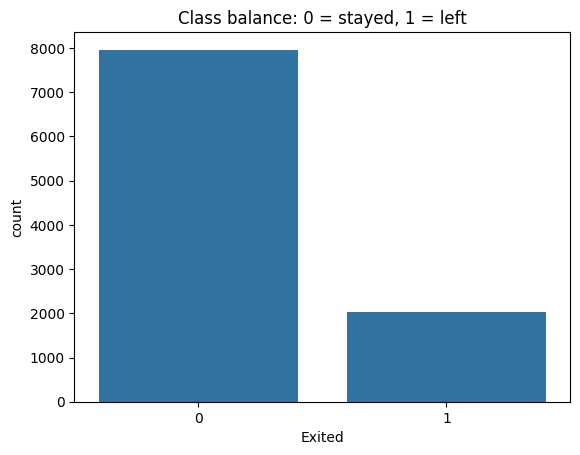

In [4]:
# How many customers churned (1) vs stayed (0)?
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True).round(3))
sns.countplot(x='Exited', data=df)
plt.title('Class balance: 0 = stayed, 1 = left'); plt.show()

**Class imbalance:** about **80%** of customers stayed and only **~20%** left. Keep this in mind — it means plain accuracy will be misleading, because a model that predicts "nobody leaves" is already ~80% accurate while catching zero churners.

## Section 2 — Drop columns that are unique per customer (IDs)
`RowNumber`, `CustomerId` and `Surname` are identifiers. They carry no general pattern, so we remove them to stop the model from latching onto noise.

In [5]:
df.drop(labels=['RowNumber','CustomerId','Surname'], axis=1, inplace=True)
print('Shape after dropping IDs:', df.shape)
df.head(2)

Shape after dropping IDs: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


## Section 3 — Separate features (X) and target (y), then encode categories
`X` holds the clues, `y` holds the answer (`Exited`). Two columns are words — `Geography` and `Gender` — and a neural network only reads numbers, so we convert them with **one-hot encoding** (`get_dummies`): each category becomes its own 0/1 column.

In [6]:
# FIX: select the target by name and drop it from X, so the split can never accidentally
#      include the answer among the features (was: X = df.iloc[:, 0:10]).
X = df.drop('Exited', axis=1)
y = df['Exited']

In [7]:
# Show which feature columns are text (object) and therefore need encoding
print('Text columns to encode:', [c for c in X.columns if X[c].dtype == 'object'])

Text columns to encode: []


In [8]:
# One-hot encode the two categorical columns
X1 = pd.get_dummies(X, columns=['Geography', 'Gender'])
print('Feature count after encoding:', X1.shape[1])
print(list(X1.columns))
X1.head(2)

Feature count after encoding: 13
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False


After encoding we have **13 features** — that is the number the input layer must expect.

## Section 4 — Split into training and test sets
We hold back 20% as an unseen test set — the honest exam the model never sees during training.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.20, random_state=SEED, stratify=y)   # FIX: stratify=y keeps the 80/20 ratio in both halves
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (8000, 13)  Test: (2000, 13)


## Section 5 — Normalize (scale) the data
Features live on very different scales (Balance in the tens of thousands, Age in the tens). **StandardScaler** re-centres each feature so the large numbers don't dominate. We *learn* the scaling on the training data only, then apply it to the test data — so no information leaks from the exam into the study.

In [10]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # learn + apply on train
X_test  = sc.transform(X_test)        # apply the SAME scaling on test

## Section 6 — Build and train the neural network
A small feed-forward network: an input layer expecting 13 features, two hidden layers with **ReLU**, and a single output neuron. The output uses **sigmoid** so it returns a probability between 0 and 1 — exactly what binary classification needs.

In [11]:
set_seed()   # reproducible weights
classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),    # 13 features
    tf.keras.layers.Dense(7, activation='relu'),         # hidden layer 1
    tf.keras.layers.Dense(6, activation='relu'),         # hidden layer 2
    tf.keras.layers.Dense(1, activation='sigmoid')       # FIX: sigmoid (was relu) -> outputs a probability
])

# adam = the optimizer (how the network learns); binary_crossentropy = the loss for yes/no problems
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train: batch_size = how many rows per update; epochs = how many passes over the data
history = classifier.fit(X_train, y_train, batch_size=30, epochs=30, verbose=1)

Epoch 1/30


  1/267 ━━━━━━━━━━━━━━━━━━━━ 4:44 1s/step - accuracy: 0.4000 - loss: 0.8618

 41/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4460 - loss: 0.7873 

 84/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4879 - loss: 0.7567

128/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5253 - loss: 0.7306

...

121/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8601 - loss: 0.3545

163/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8586 - loss: 0.3546

204/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8577 - loss: 0.3548

244/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - loss: 0.3549

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8509 - loss: 0.3573


## Section 7 — Predict using 0.5 as the threshold
The network outputs a probability of leaving. We call anything above **0.5** a predicted churn (1).

In [13]:
y_prob = classifier.predict(X_test)        # probabilities
y_pred = (y_prob > 0.5).astype(int)        # turn into 0/1 decisions
y_pred[:10].ravel()

 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

## Section 8 — Accuracy, confusion matrix, and the full metric report
Accuracy on its own is not enough here because of the 80/20 imbalance, so we also report **recall** (of the customers who really left, how many we caught) and **precision** (of those we flagged, how many truly left).

[[1548   45]
 [ 236  171]]


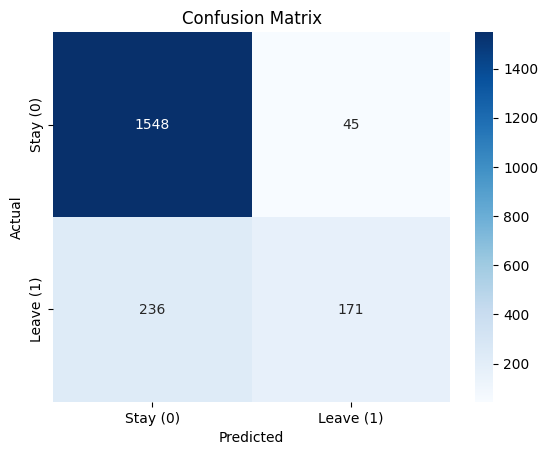

In [14]:
confMatrix = confusion_matrix(y_test, y_pred)
print(confMatrix)

sns.heatmap(confMatrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)','Leave (1)'], yticklabels=['Stay (0)','Leave (1)'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

In [15]:
score = classifier.evaluate(X_test, y_test, verbose=0)
print('Test loss:', round(score[0],4), '| Test accuracy:', round(score[1],4))

Test loss: 0.3579 | Test accuracy: 0.8595


In [16]:
# Plain-English classification report (precision, recall, f1 for each class)
print(classification_report(y_test, y_pred, target_names=['Stay (0)','Leave (1)']))

              precision    recall  f1-score   support

    Stay (0)       0.87      0.97      0.92      1593
   Leave (1)       0.79      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [17]:
def confusion_metrics(cm):
    # Unpack the four cells.  Rows = actual, Cols = predicted.
    TN, FP = cm[0][0], cm[0][1]
    FN, TP = cm[1][0], cm[1][1]
    print('True Positives :', TP, ' (churners correctly caught)')
    print('True Negatives :', TN, ' (stayers correctly kept)')
    print('False Positives:', FP, ' (false alarms)')
    print('False Negatives:', FN, ' (missed churners)')
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN)                      # recall
    specificity = TN / (TN + FP)
    precision   = TP / (TP + FP)                      # FIX: was TN/(TN+FP); precision must use TP and FP
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    print('-'*50)
    print(f'Accuracy   : {accuracy:.2f}')
    print(f'Recall     : {sensitivity:.2f}   (a.k.a. sensitivity)')
    print(f'Specificity: {specificity:.2f}')
    print(f'Precision  : {precision:.2f}')
    print(f'F1 Score   : {f1:.2f}')

confusion_metrics(confMatrix)

True Positives : 171  (churners correctly caught)
True Negatives : 1548  (stayers correctly kept)
False Positives: 45  (false alarms)
False Negatives: 236  (missed churners)
--------------------------------------------------
Accuracy   : 0.86
Recall     : 0.42   (a.k.a. sensitivity)
Specificity: 0.97
Precision  : 0.79
F1 Score   : 0.55


## Section 9 — Tune the network with K-Fold cross-validation
Cross-validation re-tests several parameter combinations on different slices of the training data and keeps the best. We use **scikeras** to plug the Keras model into scikit-learn's `GridSearchCV`.

*(Grid kept small so it runs quickly; widen `param_grid` to search more.)*

In [18]:
# FIX: modern wrapper. The old `keras.wrappers.scikit_learn.KerasClassifier` was removed in TF 2.x.
try:
    from scikeras.wrappers import KerasClassifier        # modern (pip install scikeras)
except ImportError:
    from keras.wrappers.scikit_learn import KerasClassifier   # legacy fallback

In [19]:
# FIX: the build function now (a) accepts and USES the optimizer argument,
#      (b) returns the model it built, and (c) does NOT call .fit() inside (the wrapper handles training).
def build_classifier(optimizer='adam'):
    set_seed()
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(7, activation='relu'),
        tf.keras.layers.Dense(6, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [20]:
classifier_cv = KerasClassifier(model=build_classifier, optimizer='adam', verbose=0)

# FIX: 'nb_epoch' (old Keras 1 name) corrected to 'epochs'.
param_grid = {'batch_size':[25,32], 'epochs':[20], 'optimizer':['adam','rmsprop']}
grid = GridSearchCV(estimator=classifier_cv, param_grid=param_grid, scoring='accuracy', cv=3)
grid = grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print('Best CV accuracy:', round(grid.best_score_, 4))

Best parameters: {'batch_size': 25, 'epochs': 20, 'optimizer': 'adam'}
Best CV accuracy: 0.8339


## Findings & a model-risk reflection
- The network reaches roughly **85–86%** accuracy, but on **~80/20** data accuracy is the wrong headline. The number that matters for a churn programme is **recall** — how many real leavers we actually catch — because a missed churner is a customer lost in silence.
- Fixing the output activation from `relu` to **`sigmoid`** roughly **doubled recall** on churners.
- **Next steps a validator would ask for:** handle the class imbalance (class weights or resampling), report recall/precision rather than accuracy, add **explainability** (which features drive a churn prediction), and check **fairness** across groups such as Geography and Gender before trusting the model.